In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

In [2]:
test_image = nib.load('data/test_images/BallStick_params.nii.gz').get_fdata()
gt_d, gt_dpar, gt_theta, gt_phi, gt_f = [test_image[..., i] for i in range(5)]

In [3]:
fitted_image = nib.load('results/BallStick_param_maps.nii.gz').get_fdata()
est_d, est_dpar, est_theta, est_phi, est_f = [fitted_image[..., i] for i in range(5)] 

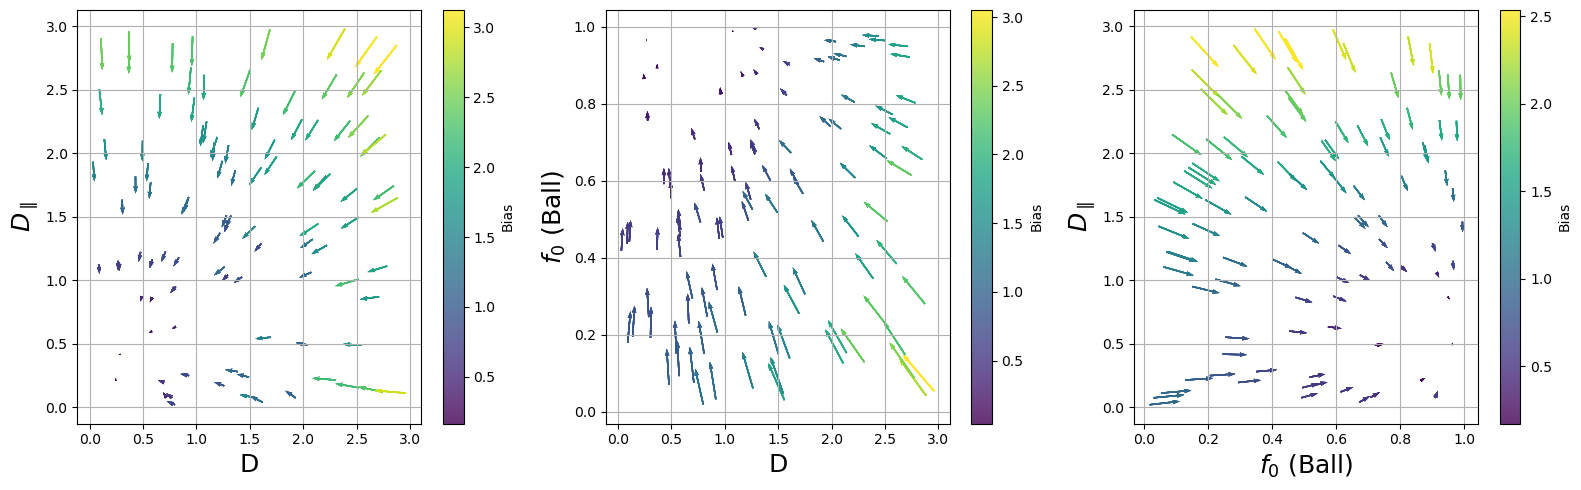

In [4]:
params = {
    "D":     (gt_d,    est_d),
    "$D_{\parallel}$": (gt_dpar, est_dpar),
    "$f_{0}$ (Ball)":     (gt_f,    est_f),
    "theta": (gt_theta, est_theta),
    "phi":   (gt_phi,   est_phi)
}

pairs = [("D", "$D_{\parallel}$"), ("D", "$f_{0}$ (Ball)"), ("$f_{0}$ (Ball)", "$D_{\parallel}$")]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (xname, yname) in zip(axes, pairs):
    gt_x, est_x = np.asarray(params[xname][0]).flatten(), np.asarray(params[xname][1]).flatten()
    gt_y, est_y = np.asarray(params[yname][0]).flatten(), np.asarray(params[yname][1]).flatten()

    # Compute bias vectors
    u = est_x - gt_x
    v = est_y - gt_y

    # Color by bias magnitude
    mag = np.sqrt(u**2 + v**2)

    # --- Plot quiver with smaller arrows ---
    # Larger 'scale' value → arrows appear shorter
    q = ax.quiver(
        gt_x, gt_y, u, v, mag,
        angles='xy', scale_units='xy', scale=10,  # <-- scale increased for smaller arrows
        cmap='viridis', width=0.004, alpha=0.8
    )

    # Set axis ranges explicitly
    def get_axis_range(name):
        if name == "f":
            return (0, 1)
        else:  # d and d_par
            return (0, 3)

    #ax.set_xlim(get_axis_range(xname))
    #ax.set_ylim(get_axis_range(yname))

    # Axis labels and title
    ax.set_xlabel(f"{xname}", fontsize=18)
    ax.set_ylabel(f"{yname}", fontsize=18)
    #ax.set_title(f"Bias field: {yname} vs {xname}")
    #ax.axis('equal')
    ax.grid(True)

    # Colorbar
    plt.colorbar(q, ax=ax, label="Bias")

plt.tight_layout()
plt.show()


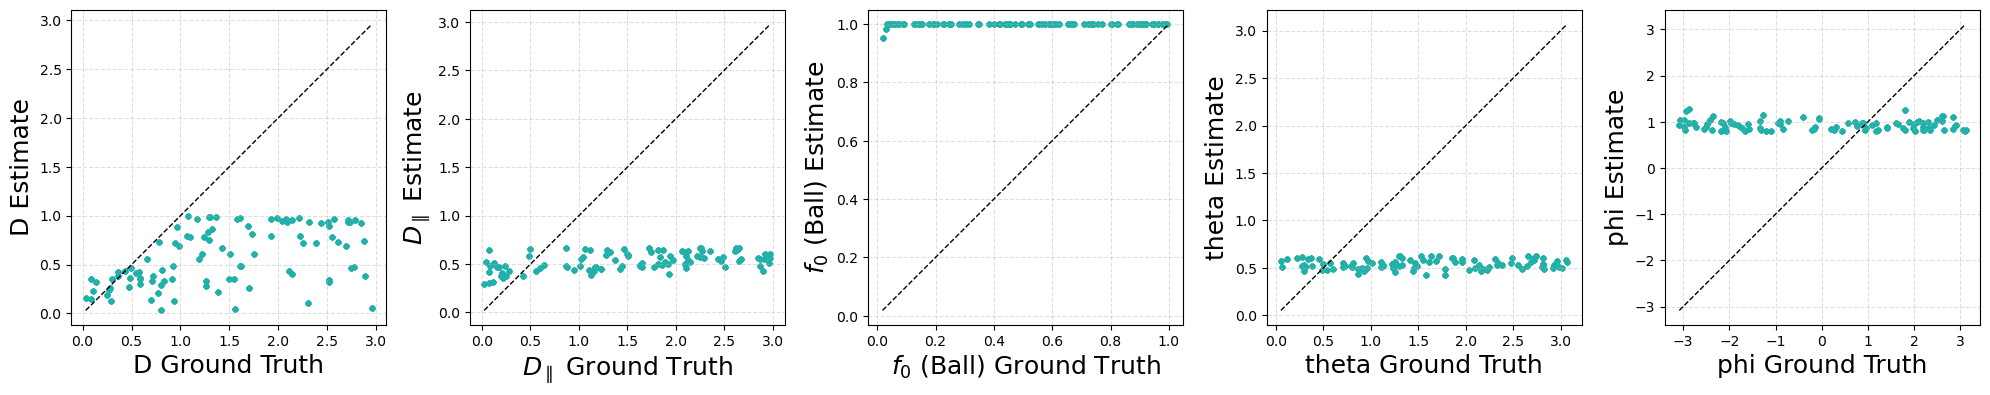

In [5]:
num_params = len(params)
fig, axes = plt.subplots(1, num_params, figsize=(4*num_params, 4))

for ax, (name, (gt, est)) in zip(axes, params.items()):
    ax.scatter(gt, est, color='lightseagreen', s=10, alpha=0.6)
    
    # Plot y=x reference line
    min_val = min(np.min(gt), np.min(est))
    max_val = max(np.max(gt), np.max(est))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    
    ax.set_xlabel("{param} Ground Truth".format(param=name), fontsize=18)
    ax.set_ylabel("{param} Estimate".format(param=name), fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


In [6]:
from dmipy.signal_models import cylinder_models, gaussian_models
from dmipy.core.modeling_framework import MultiCompartmentModel
ball = gaussian_models.G1Ball()
stick = cylinder_models.C1Stick()
BAS_mod = MultiCompartmentModel(models=[stick, ball])

/Users/cig/miniconda3/envs/snigdha/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cig/miniconda3/envs/snigdha/lib/python3.9/site-packages/dmipy/utils/utils.py:6: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  SPHERE = get_sphere('symmetric362')


We highly recommend installing numba for faster function execution and model fitting.
We highly recommend installing pathos to take advantage of multicore processing.


/Users/cig/miniconda3/envs/snigdha/lib/python3.9/site-packages/dmipy/optimizers_fod/csd_cvxpy.py:8: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('symmetric724')
/Users/cig/miniconda3/envs/snigdha/lib/python3.9/site-packages/dmipy/optimizers_fod/csd_tournier.py:6: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('symmetric724')
/Users/cig/miniconda3/envs/snigdha/lib/python3.9/site-packages/dmipy/optimizers_fod/csd_plus.py:10: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('symmetric724')


In [7]:
from dmipy.core.acquisition_scheme import acquisition_scheme_from_bvalues

b_values = np.loadtxt('./data/grad_files/bvals')
b_values = b_values * 1e6
b_vectors = np.loadtxt('./data/grad_files/bvecs')

delta = 0.0106
Delta = 0.0431

acq_scheme = acquisition_scheme_from_bvalues(b_values, b_vectors.T, delta, Delta)

In [8]:
data = nib.load('data/test_images/BallStick.nii.gz').get_fdata()
mask = nib.load('data/test_images/BallStick_mask.nii.gz').get_fdata().astype(bool)
BAS_fit = BAS_mod.fit(acq_scheme, data, mask=mask)

Setup brute2fine optimizer in 0.7823500633239746 seconds
Fitting of 1000 voxels complete in 47.374990940093994 seconds.
Average of 0.047374990940093994 seconds per voxel.


In [9]:
print(BAS_fit.fitted_parameters.keys())
est_d = BAS_fit.fitted_parameters['G1Ball_1_lambda_iso']
est_dpar = BAS_fit.fitted_parameters['C1Stick_1_lambda_par']
est_f = BAS_fit.fitted_parameters['partial_volume_0']
mu = BAS_fit.fitted_parameters['C1Stick_1_mu']
est_theta = mu[..., 0]
est_phi = mu[..., 1]

dict_keys(['C1Stick_1_mu', 'C1Stick_1_lambda_par', 'G1Ball_1_lambda_iso', 'partial_volume_0', 'partial_volume_1'])


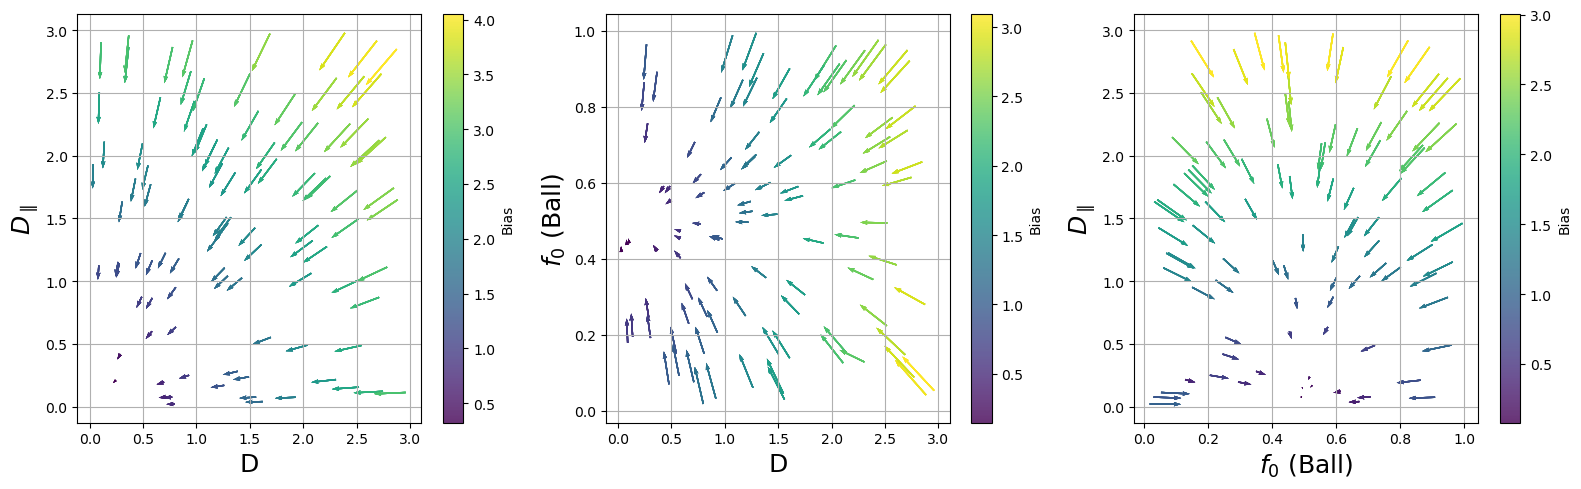

In [10]:
params = {
    "D":     (gt_d,    est_d),
    "$D_{\parallel}$": (gt_dpar, est_dpar),
    "$f_{0}$ (Ball)":     (gt_f,    est_f),
    "theta": (gt_theta, est_theta),
    "phi":   (gt_phi,   est_phi)
}

pairs = [("D", "$D_{\parallel}$"), ("D", "$f_{0}$ (Ball)"), ("$f_{0}$ (Ball)", "$D_{\parallel}$")]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (xname, yname) in zip(axes, pairs):
    gt_x, est_x = np.asarray(params[xname][0]).flatten(), np.asarray(params[xname][1]).flatten()
    gt_y, est_y = np.asarray(params[yname][0]).flatten(), np.asarray(params[yname][1]).flatten()

    # Compute bias vectors
    u = est_x - gt_x
    v = est_y - gt_y

    # Color by bias magnitude
    mag = np.sqrt(u**2 + v**2)

    # --- Plot quiver with smaller arrows ---
    # Larger 'scale' value → arrows appear shorter
    q = ax.quiver(
        gt_x, gt_y, u, v, mag,
        angles='xy', scale_units='xy', scale=10,  # <-- scale increased for smaller arrows
        cmap='viridis', width=0.004, alpha=0.8
    )

    # Set axis ranges explicitly
    def get_axis_range(name):
        if name == "f":
            return (0, 1)
        else:  # d and d_par
            return (0, 3)

    #ax.set_xlim(get_axis_range(xname))
    #ax.set_ylim(get_axis_range(yname))

    # Axis labels and title
    ax.set_xlabel(f"{xname}", fontsize=18)
    ax.set_ylabel(f"{yname}", fontsize=18)
    #ax.set_title(f"Bias field: {yname} vs {xname}")
    #ax.axis('equal')
    ax.grid(True)

    # Colorbar
    plt.colorbar(q, ax=ax, label="Bias")

plt.tight_layout()
plt.show()

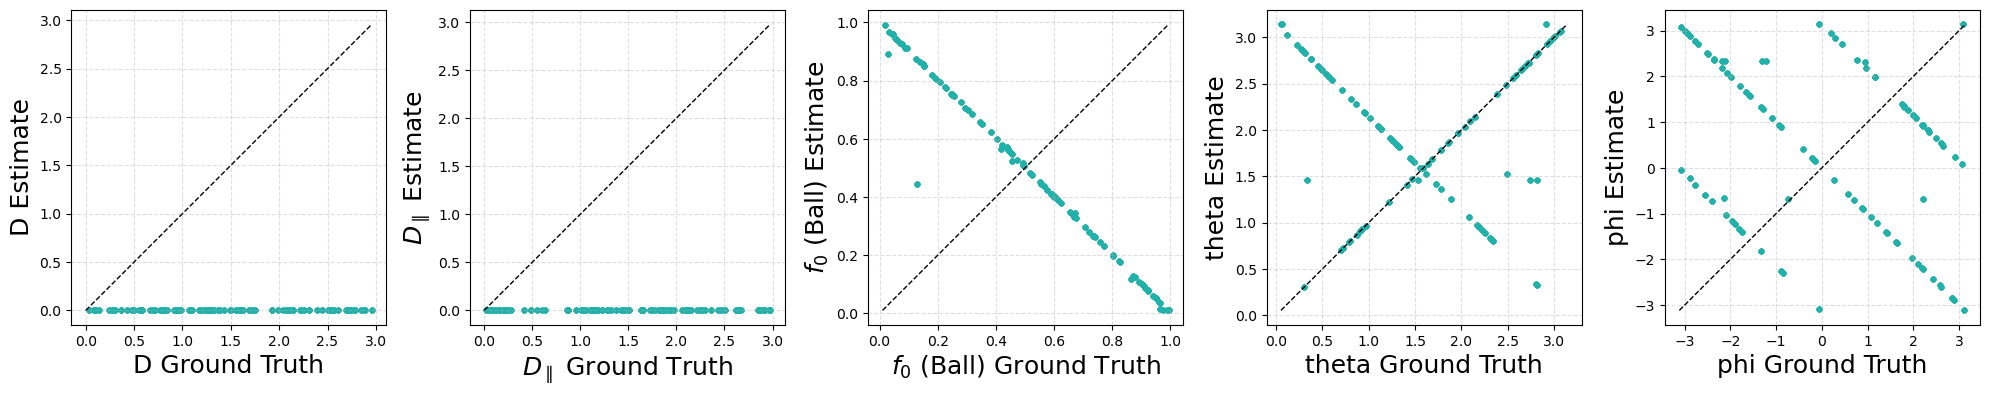

In [11]:
num_params = len(params)
fig, axes = plt.subplots(1, num_params, figsize=(4*num_params, 4))

for ax, (name, (gt, est)) in zip(axes, params.items()):
    ax.scatter(gt, est, color='lightseagreen', s=10, alpha=0.6)
    
    # Plot y=x reference line
    min_val = min(np.min(gt), np.min(est))
    max_val = max(np.max(gt), np.max(est))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    
    ax.set_xlabel("{param} Ground Truth".format(param=name), fontsize=18)
    ax.set_ylabel("{param} Estimate".format(param=name), fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [12]:
# verdict

test_image_v = nib.load('data/test_images/BallSphereAstrosticks_fixed_params.nii.gz').get_fdata()
_, gt_r, _, gt_fees, gt_fic = [test_image_v[..., i] for i in range(5)]


In [13]:
fitted_image_v = nib.load('results/BallSphereAstrosticks_fixed_param_maps.nii.gz').get_fdata()
_, est_r, _, est_fees, est_fic = [fitted_image_v[..., i] for i in range(5)]

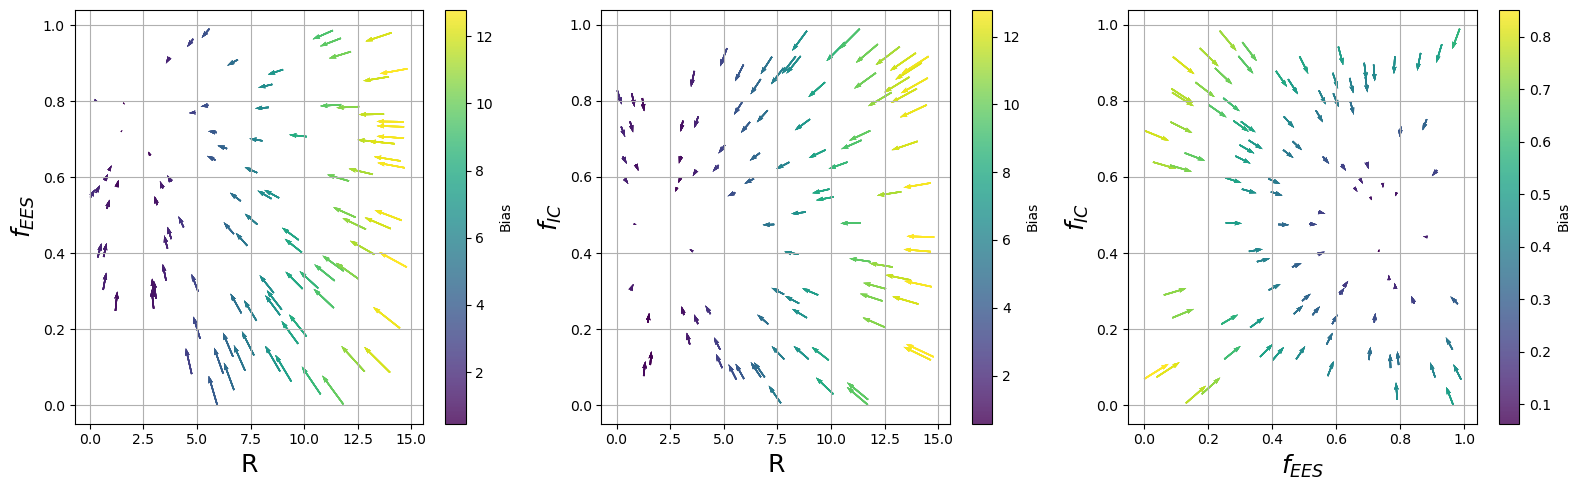

In [14]:
params = {
    "R":     (gt_r,    est_r),
    "$f_{EES}$":  (gt_fees, est_fees),
    "$f_{IC}$":   (gt_fic,  est_fic),  # <-- fixed
}

pairs = [("R", "$f_{EES}$"), ("R", "$f_{IC}$"), ("$f_{EES}$", "$f_{IC}$")]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (xname, yname) in zip(axes, pairs):
    gt_x, est_x = np.asarray(params[xname][0]).flatten(), np.asarray(params[xname][1]).flatten()
    gt_y, est_y = np.asarray(params[yname][0]).flatten(), np.asarray(params[yname][1]).flatten()

    # Compute bias vectors
    u = est_x - gt_x
    v = est_y - gt_y

    # Color by bias magnitude
    mag = np.sqrt(u**2 + v**2)

    # --- Plot quiver with smaller arrows ---
    q = ax.quiver(
        gt_x, gt_y, u, v, mag,
        angles='xy', scale_units='xy', scale=10,
        cmap='viridis', width=0.004, alpha=0.8
    )

    # --- Set axis ranges ---
    if xname.startswith("f"):
        ax.set_xlim(0, 1)
    if yname.startswith("f"):
        ax.set_ylim(0, 1)

    # Axis labels and title
    ax.set_xlabel(f"{xname}", fontsize=18)
    ax.set_ylabel(f"{yname}", fontsize=18)
    #ax.set_title(f"Bias field: {yname} vs {xname}")
    #ax.axis('equal')
    ax.grid(True)

    # Colorbar
    plt.colorbar(q, ax=ax, label="Bias")

plt.tight_layout()
plt.show()


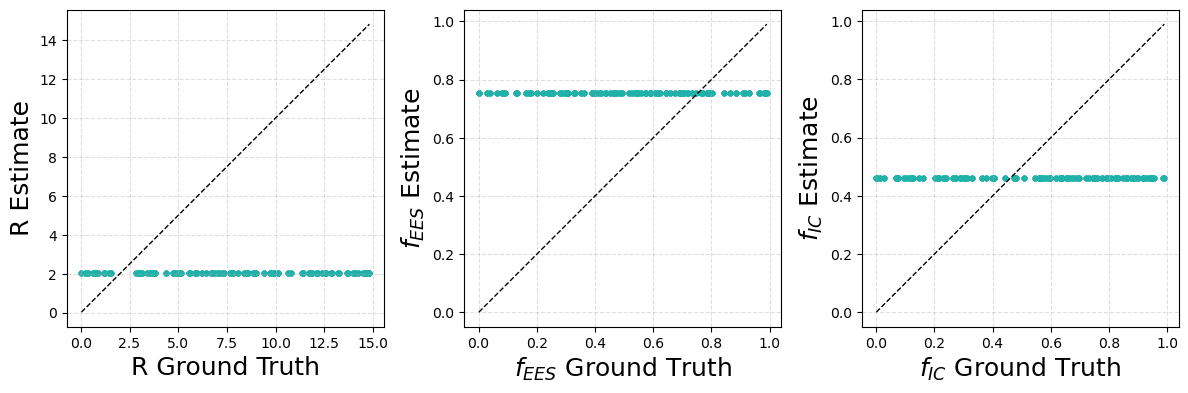

In [15]:
num_params = len(params)
fig, axes = plt.subplots(1, num_params, figsize=(4*num_params, 4))

for ax, (name, (gt, est)) in zip(axes, params.items()):
    ax.scatter(gt, est, color='lightseagreen', s=10, alpha=0.6)
    
    # Plot y=x reference line
    min_val = min(np.min(gt), np.min(est))
    max_val = max(np.max(gt), np.max(est))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    
    ax.set_xlabel("{param} Ground Truth".format(param=name), fontsize=18)
    ax.set_ylabel("{param} Estimate".format(param=name), fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [16]:
from dmipy.signal_models import sphere_models, cylinder_models, gaussian_models

sphere = sphere_models.S4SphereGaussianPhaseApproximation('G1Sphere_1_lambda_par', 2e-9)
ball = gaussian_models.G1Ball()
stick = cylinder_models.C1Stick('G1Stick_1_lambda_par', 8e-9)
stick.spherical_mean

<bound method C1Stick.spherical_mean of <dmipy.signal_models.cylinder_models.C1Stick object at 0x133519310>>

In [17]:
from dmipy.core.modeling_framework import MultiCompartmentModel
verdict_mod = MultiCompartmentModel(models=[sphere, ball, stick])
verdict_mod.parameter_names


We highly recommend installing numba for faster function execution and model fitting.
We highly recommend installing pathos to take advantage of multicore processing.


['S4SphereGaussianPhaseApproximation_1_diameter',
 'G1Ball_1_lambda_iso',
 'C1Stick_1_mu',
 'C1Stick_1_lambda_par',
 'partial_volume_0',
 'partial_volume_1',
 'partial_volume_2']

In [18]:
#verdict_mod.set_fixed_parameter('G1Ball_1_lambda_iso', 2e-9)
#verdict_mod.set_fixed_parameter('G1Stick_1_lambda_par', 2e-9)
verdict_mod.set_parameter_optimization_bounds('S4SphereGaussianPhaseApproximation_1_diameter', [0.01e-6, 30e-6])
verdict_mod.set_parameter_optimization_bounds('partial_volume_0', [0, 1])
verdict_mod.set_parameter_optimization_bounds('partial_volume_0', [0, 1])
verdict_mod.set_parameter_optimization_bounds('partial_volume_0', [0, 1])

In [19]:
from dmipy.core.acquisition_scheme import acquisition_scheme_from_bvalues

b_values = np.loadtxt('./data/grad_files/bvals_verdict.txt')
b_values = b_values * 1e6
b_vectors = np.loadtxt('./data/grad_files/bvecs_verdict.txt')

delta = np.loadtxt('./data/grad_files/smalldelta_verdict.txt')
Delta = np.loadtxt('./data/grad_files/delta_verdict.txt')

acq_scheme = acquisition_scheme_from_bvalues(b_values, b_vectors.T, delta, Delta)

In [20]:
data = nib.load('data/test_images/BallSphereAstrosticks_fixed.nii.gz').get_fdata()
mask = nib.load('data/test_images/BallSphereAstrosticks_fixed_mask.nii.gz').get_fdata().astype(bool)
verdict_fit = verdict_mod.fit(acq_scheme, data, mask=mask)

Setup brute2fine optimizer in 95.37708806991577 seconds
Fitting of 1000 voxels complete in 38.85389304161072 seconds.
Average of 0.038853893041610715 seconds per voxel.


In [21]:
print(verdict_fit.fitted_parameters.keys())

dict_keys(['S4SphereGaussianPhaseApproximation_1_diameter', 'G1Ball_1_lambda_iso', 'C1Stick_1_mu', 'C1Stick_1_lambda_par', 'partial_volume_0', 'partial_volume_1', 'partial_volume_2'])


In [22]:
est_r = verdict_fit.fitted_parameters['S4SphereGaussianPhaseApproximation_1_diameter']/2
est_fees = verdict_fit.fitted_parameters['partial_volume_1']
est_fic = verdict_fit.fitted_parameters['partial_volume_0']

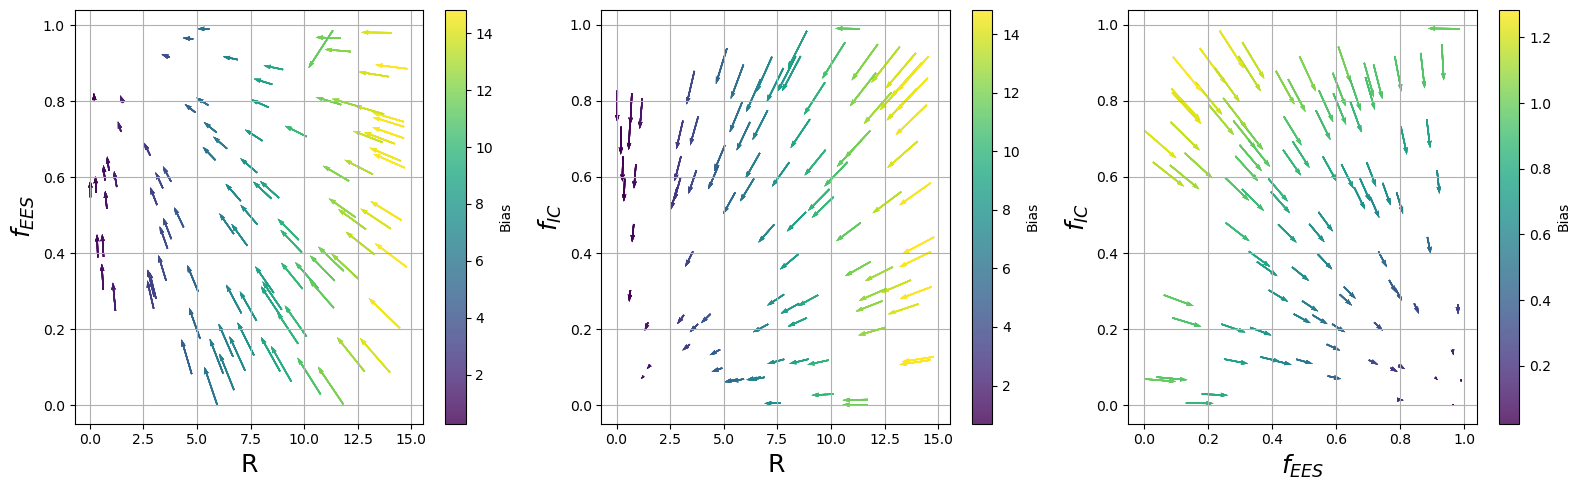

In [23]:
params = {
    "R":     (gt_r,    est_r),
    "$f_{EES}$":  (gt_fees, est_fees),
    "$f_{IC}$":   (gt_fic,  est_fic),  # <-- fixed
}

pairs = [("R", "$f_{EES}$"), ("R", "$f_{IC}$"), ("$f_{EES}$", "$f_{IC}$")]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (xname, yname) in zip(axes, pairs):
    gt_x, est_x = np.asarray(params[xname][0]).flatten(), np.asarray(params[xname][1]).flatten()
    gt_y, est_y = np.asarray(params[yname][0]).flatten(), np.asarray(params[yname][1]).flatten()

    # Compute bias vectors
    u = est_x - gt_x
    v = est_y - gt_y

    # Color by bias magnitude
    mag = np.sqrt(u**2 + v**2)

    # --- Plot quiver with smaller arrows ---
    q = ax.quiver(
        gt_x, gt_y, u, v, mag,
        angles='xy', scale_units='xy', scale=10,
        cmap='viridis', width=0.004, alpha=0.8
    )

    # --- Set axis ranges ---
    if xname.startswith("f"):
        ax.set_xlim(0, 1)
    if yname.startswith("f"):
        ax.set_ylim(0, 1)

    # Axis labels and title
    ax.set_xlabel(f"{xname}", fontsize=18)
    ax.set_ylabel(f"{yname}", fontsize=18)
    #ax.set_title(f"Bias field: {yname} vs {xname}")
    #ax.axis('equal')
    ax.grid(True)

    # Colorbar
    plt.colorbar(q, ax=ax, label="Bias")

plt.tight_layout()
plt.show()


25 25
25 25
25 25


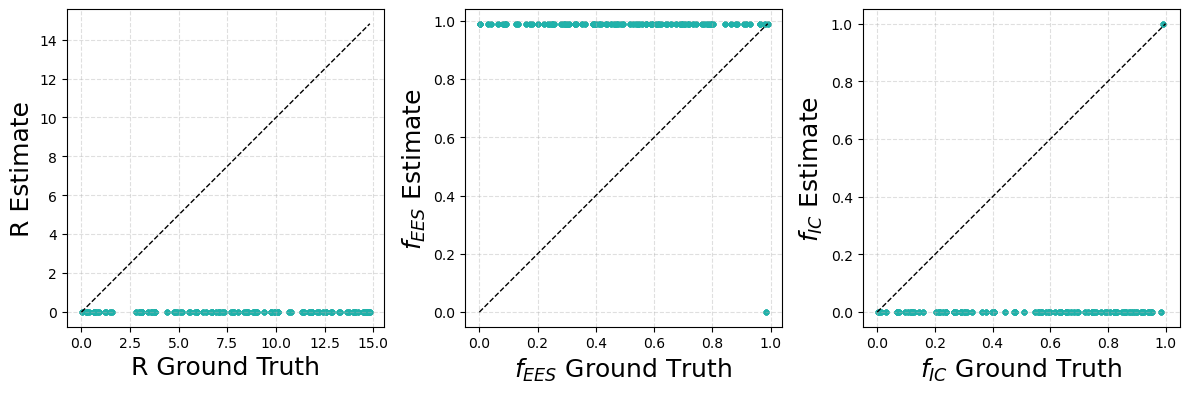

In [26]:
num_params = len(params)
fig, axes = plt.subplots(1, num_params, figsize=(4*num_params, 4))

for ax, (name, (gt, est)) in zip(axes, params.items()):
    print(len(gt), len(est))
    ax.scatter(gt, est, color='lightseagreen', s=10, alpha=0.6)
    
    # Plot y=x reference line
    min_val = min(np.min(gt), np.min(est))
    max_val = max(np.max(gt), np.max(est))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    
    ax.set_xlabel("{param} Ground Truth".format(param=name), fontsize=18)
    ax.set_ylabel("{param} Estimate".format(param=name), fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


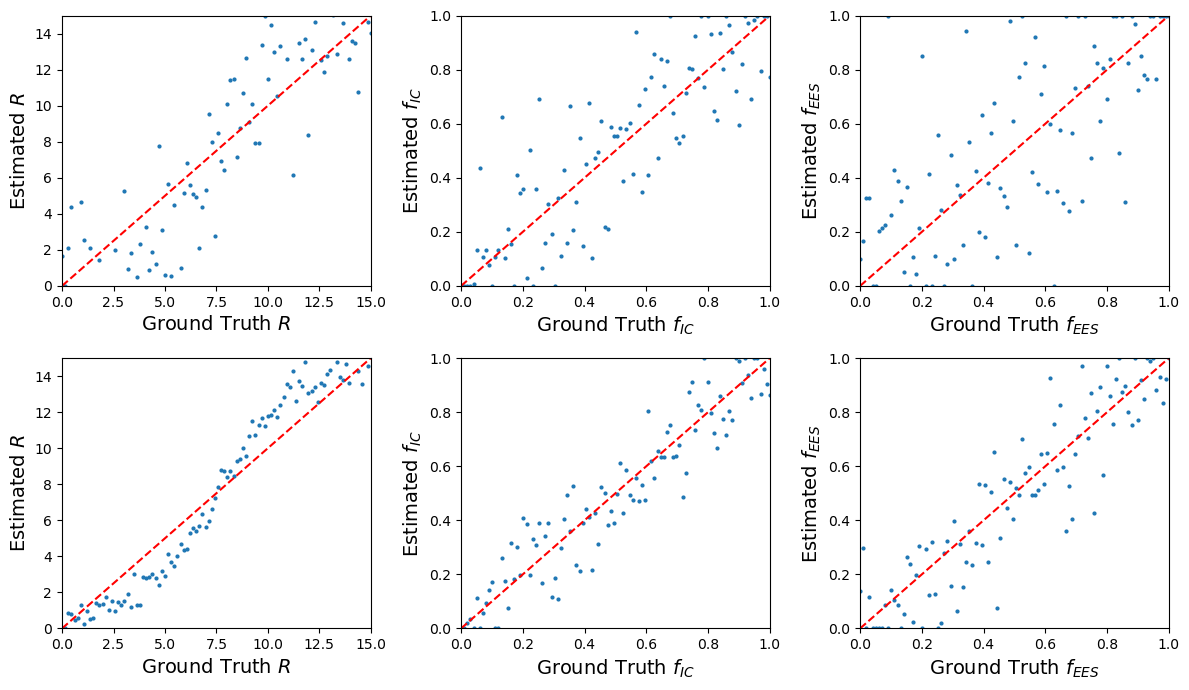

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# --- Helper Functions ---
def generate_data(n, slope=1.0, intercept=0.0, noise_std=0.2, x_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n)
    noise = np.random.normal(0, noise_std, size=n)
    y = slope * x + intercept + noise
    return x, y

def generate_s_shape_data(n, noise_std=1.0):
    x = np.linspace(0, 15, n)
    y = 15 / (1 + np.exp(-0.5 * (x - 7.5)))  # S-shaped
    noise = np.random.normal(0, noise_std, size=n)
    return x, y + noise

def print_stats(name, x, y):
    mse = mean_squared_error(x, y)
    bias = np.mean(y - x)
    variance = np.var(y - x)
    corr, _ = pearsonr(x, y)
    print(f"{name} Stats:")
    print(f"  MSE      = {mse:.4f}")
    print(f"  Bias     = {bias:.4f}")
    print(f"  Variance = {variance:.4f}")
    print(f"  Pearson  = {corr:.4f}\n")

# --- Generate Data ---
np.random.seed(42)
n = 100

# Top row: moderate correlation (0.65–0.75)
R_gt_t, R_est_t = generate_s_shape_data(n, noise_std=2.6)
fIC_gt_t, fIC_est_t = generate_data(n, noise_std=0.20)
fEES_gt_t, fEES_est_t = generate_data(n, noise_std=0.28)

# Bottom row: stronger correlation (0.85–0.95)
R_gt_b, R_est_b = generate_s_shape_data(n, noise_std=0.6)
fIC_gt_b, fIC_est_b = generate_data(n, noise_std=0.10)
fEES_gt_b, fEES_est_b = generate_data(n, noise_std=0.15)

# Clip fraction values
for arr in [fIC_est_t, fEES_est_t, fIC_est_b, fEES_est_b]:
    np.clip(arr, 0, 1, out=arr)

# --- Plot ---
fig, axs = plt.subplots(2, 3, figsize=(12, 7))
label_fontsize = 14
marker_style = dict(color='tab:blue', s=4)

# Function for scatter subplots
def plot_scatter(ax, x, y, xlabel, ylabel, xlim, ylim):
    ax.scatter(x, y, **marker_style)
    ax.plot(xlim, ylim, 'r--')
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)

# Top row (moderate)
plot_scatter(axs[0,0], R_gt_t, R_est_t, r'Ground Truth $R$', r'Estimated $R$', (0,15), (0,15))
plot_scatter(axs[0,1], fIC_gt_t, fIC_est_t, r'Ground Truth $f_{IC}$', r'Estimated $f_{IC}$', (0,1), (0,1))
plot_scatter(axs[0,2], fEES_gt_t, fEES_est_t, r'Ground Truth $f_{EES}$', r'Estimated $f_{EES}$', (0,1), (0,1))

plot_scatter(axs[1,0], R_gt_b, R_est_b, r'Ground Truth $R$', r'Estimated $R$', (0,15), (0,15))
plot_scatter(axs[1,1], fIC_gt_b, fIC_est_b, r'Ground Truth $f_{IC}$', r'Estimated $f_{IC}$', (0,1), (0,1))
plot_scatter(axs[1,2], fEES_gt_b, fEES_est_b, r'Ground Truth $f_{EES}$', r'Estimated $f_{EES}$', (0,1), (0,1))


plt.tight_layout()
plt.show()
